<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">

*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Density and Contour Plots](04.04-Density-and-Contour-Plots.ipynb) | [Contents](Index.ipynb) | [Customizing Plot Legends](04.06-Customizing-Legends.ipynb) >

<a href="https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.05-Histograms-and-Binnings.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>


# Histograms, Binnings, and Density

A simple histogram can be a great first step in understanding a dataset.
Earlier, we saw a preview of Matplotlib's histogram function (see [Comparisons, Masks, and Boolean Logic](02.06-Boolean-Arrays-and-Masks.ipynb)), which creates a basic histogram in one line, once the normal boiler-plate imports are done:

In [7]:
#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-white')

data = np.random.randn(1000)

/tmp/ipykernel_1809445/918842553.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


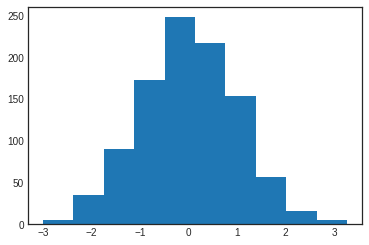

In [8]:
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display; 
here's an example of a more customized histogram:

AttributeError: Polygon.set() got an unexpected keyword argument 'normed'

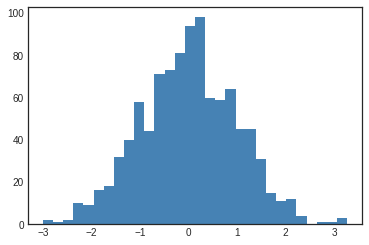

In [9]:
plt.hist(data, bins=30, normed=True, alpha=0.5,
         histtype='stepfilled', color='steelblue',
         edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

AttributeError: Polygon.set() got an unexpected keyword argument 'normed'

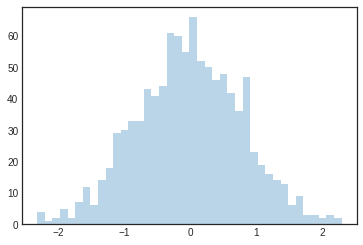

In [12]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, normed=True, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [11]:
counts, bin_edges = np.histogram(data, bins=5)
print(counts)

[ 40 263 465 211  21]


## Two-Dimensional Histograms and Binnings

Just as we create histograms in one dimension by dividing the number-line into bins, we can also create histograms in two-dimensions by dividing points among two-dimensional bins.
We'll take a brief look at several ways to do this here.
We'll start by defining some data—an ``x`` and ``y`` array drawn from a multivariate Gaussian distribution:

In [10]:
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

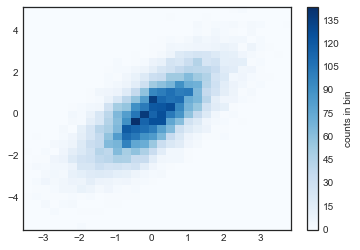

In [12]:
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [13]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

For the generalization of this histogram binning in dimensions higher than two, see the ``np.histogramdd`` function.

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

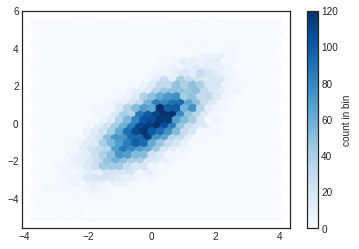

In [14]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

``plt.hexbin`` has a number of interesting options, including the ability to specify weights for each point, and to change the output in each bin to any NumPy aggregate (mean of weights, standard deviation of weights, etc.).

### Kernel density estimation

Another common method of evaluating densities in multiple dimensions is *kernel density estimation* (KDE).
This will be discussed more fully in [In-Depth: Kernel Density Estimation](05.13-Kernel-Density-Estimation.ipynb), but for now we'll simply mention that KDE can be thought of as a way to "smear out" the points in space and add up the result to obtain a smooth function.
One extremely quick and simple KDE implementation exists in the ``scipy.stats`` package.
Here is a quick example of using the KDE on this data:

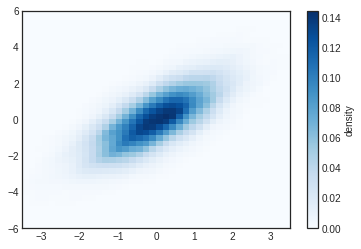

In [15]:
from scipy.stats import gaussian_kde

# fit an array of size [Ndim, Nsamples]
data = np.vstack([x, y])
kde = gaussian_kde(data)

# evaluate on a regular grid
xgrid = np.linspace(-3.5, 3.5, 40)
ygrid = np.linspace(-6, 6, 40)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
Z = kde.evaluate(np.vstack([Xgrid.ravel(), Ygrid.ravel()]))

# Plot the result as an image
plt.imshow(Z.reshape(Xgrid.shape),
           origin='lower', aspect='auto',
           extent=[-3.5, 3.5, -6, 6],
           cmap='Blues')
cb = plt.colorbar()
cb.set_label("density")

KDE has a smoothing length that effectively slides the knob between detail and smoothness (one example of the ubiquitous bias–variance trade-off).
The literature on choosing an appropriate smoothing length is vast: ``gaussian_kde`` uses a rule-of-thumb to attempt to find a nearly optimal smoothing length for the input data.

Other KDE implementations are available within the SciPy ecosystem, each with its own strengths and weaknesses; see, for example, ``sklearn.neighbors.KernelDensity`` and ``statsmodels.nonparametric.kernel_density.KDEMultivariate``.
For visualizations based on KDE, using Matplotlib tends to be overly verbose.
The Seaborn library, discussed in [Visualization With Seaborn](04.14-Visualization-With-Seaborn.ipynb), provides a much more terse API for creating KDE-based visualizations.

# Small general exercises

## Ćwiczenie 1 — `np.linspace`

Funkcja `np.linspace(a, b, n)` tworzy `n` równo rozmieszczonych punktów od `a` do `b`.

Sprawdzimy:
- jakie wartości zwraca,
- jaki ma kształt,
- czym różni się od zwykłej listy.

In [16]:
import numpy as np

x = np.linspace(0, 10, 5)
print(x)
print("shape:", x.shape)
print("type:", type(x))

[ 0.   2.5  5.   7.5 10. ]
shape: (5,)
type: <class 'numpy.ndarray'>


### Zadanie
1. Zmień liczbę punktów z `5` na `11`.
2. Sprawdź, czy końce przedziału są wliczone.
3. Utwórz wektor od `-3` do `3` z 7 punktami.

## Ćwiczenie 2 — `reshape`

Czasem mamy dane zapisane jako jeden długi wektor, a chcemy widzieć je jako tablicę 2D.

`reshape` nie zmienia danych, tylko ich układ.

In [17]:
a = np.arange(12)
print("a =", a)
print("shape:", a.shape)

A = a.reshape(3, 4)
print("\nPo reshape(3,4):")
print(A)
print("shape:", A.shape)

a = [ 0  1  2  3  4  5  6  7  8  9 10 11]
shape: (12,)

Po reshape(3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)


### Zadanie
1. Zmień `reshape(3,4)` na `reshape(4,3)`.
2. Spróbuj `reshape(2,6)`.
3. Zastanów się: dlaczego `reshape(5,3)` nie działa?

## Ćwiczenie 3 — `ravel`

`ravel()` zamienia tablicę wielowymiarową na jeden długi wektor.

To jest bardzo ważne, gdy mamy siatkę 2D, a chcemy przekazać punkty do funkcji, która oczekuje listy punktów.

In [19]:
A = np.arange(12).reshape(3, 4)
print("A:")
print(A)

flat = A.ravel()
print("\nA.ravel():")
print(flat)
print("shape:", flat.shape)

A:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

A.ravel():
[ 0  1  2  3  4  5  6  7  8  9 10 11]
shape: (12,)


### Zadanie
1. Sprawdź, co daje `A.reshape(12)`.
2. Porównaj wynik `ravel()` i `reshape(-1)`.
3. Spróbuj narysować sobie odpowiadające pozycje:
   - `A[0,0]`
   - `A[0,1]`
   - `A[1,0]`
   i zobacz, w jakiej kolejności trafiają do `flat`.

## Ćwiczenie 4 — `np.meshgrid`

`meshgrid` bierze dwa wektory:
- wartości osi `x`,
- wartości osi `y`,

i tworzy pełną siatkę punktów 2D.

To jest kluczowe do rysowania funkcji dwóch zmiennych.

In [21]:
x = np.array([10, 20, 30])
y = np.array([1, 2, 3, 4])

X, Y = np.meshgrid(x, y)

print("X:")
print(X)
print("shape X:", X.shape)

print("\nY:")
print(Y)
print("shape Y:", Y.shape)

X:
[[10 20 30]
 [10 20 30]
 [10 20 30]
 [10 20 30]]
shape X: (4, 3)

Y:
[[1 1 1]
 [2 2 2]
 [3 3 3]
 [4 4 4]]
shape Y: (4, 3)


### Co zobaczyć
- `X` powiela wartości `x` w wierszach,
- `Y` powiela wartości `y` w kolumnach.

Każda para:
- `(X[i,j], Y[i,j])`

to jeden punkt siatki.

### Zadanie
Wypisz ręcznie punkty:
- `(X[0,0], Y[0,0])`
- `(X[0,1], Y[0,1])`
- `(X[2,1], Y[2,1])`

i sprawdź, czy zgadzają się z intuicją.

## Ćwiczenie 5 — zobacz siatkę jako punkty

Teraz narysujemy wszystkie punkty z `meshgrid`, żeby zobaczyć, co naprawdę powstaje.

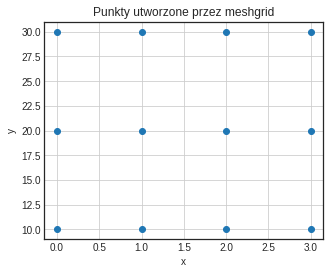

In [22]:
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3])
y = np.array([10, 20, 30])

X, Y = np.meshgrid(x, y)

plt.figure(figsize=(5, 4))
plt.scatter(X, Y)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Punkty utworzone przez meshgrid")
plt.show()

## Ćwiczenie 6 — dlaczego używamy `ravel()` po `meshgrid()`?

`meshgrid` daje dwie tablice 2D:
- `X`
- `Y`

Ale wiele funkcji numerycznych chce dane w postaci listy punktów:
- `(x1, y1), (x2, y2), ...`

Dlatego spłaszczamy `X` i `Y`.

In [23]:
x = np.array([0, 1, 2])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)

print("X:")
print(X)
print("\nY:")
print(Y)

xr = X.ravel()
yr = Y.ravel()

print("\nX.ravel():", xr)
print("Y.ravel():", yr)

X:
[[0 1 2]
 [0 1 2]]

Y:
[[10 10 10]
 [20 20 20]]

X.ravel(): [0 1 2 0 1 2]
Y.ravel(): [10 10 10 20 20 20]


### Obserwacja
Elementy o tych samych indeksach odpowiadają sobie:
- `(xr[0], yr[0])`
- `(xr[1], yr[1])`
- itd.

To są kolejne punkty siatki zapisane w formie listy.

## Ćwiczenie 7 — `np.vstack`

`vstack` układa tablice pionowo, czyli jedna pod drugą.

W KDE często chcemy mieć dane w formie:

\[
\begin{bmatrix}
x_1 & x_2 & \dots \\
y_1 & y_2 & \dots
\end{bmatrix}
\]

czyli shape `(2, N)`.

In [24]:
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])

data = np.vstack([x, y])

print(data)
print("shape:", data.shape)

[[ 1  2  3  4]
 [10 20 30 40]]
shape: (2, 4)


### Zadanie
1. Sprawdź `np.vstack([y, x])`.
2. Sprawdź `np.column_stack([x, y])`.
3. Porównaj kształty i zrozum różnicę:
   - `(2, N)`
   - `(N, 2)`

## Ćwiczenie 8 — dwie różne reprezentacje tych samych punktów

Punkty 2D można zapisać na dwa sposoby:

1. jako dwa wiersze:
\[
\begin{bmatrix}
x_1 & x_2 & \dots \\
y_1 & y_2 & \dots
\end{bmatrix}
\]

2. jako listę punktów:
\[
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
\vdots & \vdots
\end{bmatrix}
\]

In [25]:
x = np.array([1, 2, 3])
y = np.array([10, 20, 30])

A = np.vstack([x, y])
B = np.column_stack([x, y])

print("vstack:")
print(A)
print("shape:", A.shape)

print("\ncolumn_stack:")
print(B)
print("shape:", B.shape)

vstack:
[[ 1  2  3]
 [10 20 30]]
shape: (2, 3)

column_stack:
[[ 1 10]
 [ 2 20]
 [ 3 30]]
shape: (3, 2)


### Pytanie
Która wersja:
- lepiej pasuje do `gaussian_kde`?
- a która lepiej pasuje do „listy punktów” w stylu ML?

## Ćwiczenie 9 — liczenie funkcji na siatce

Zbudujemy siatkę punktów i policzymy na niej funkcję:

\[
Z = X^2 + Y^2
\]

To pokaże, jak przechodzimy od punktów do wartości na obrazie 2D.

In [26]:
x = np.linspace(-2, 2, 5)
y = np.linspace(-3, 3, 7)

X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Z shape:", Z.shape)

print("\nZ:")
print(Z)

X shape: (7, 5)
Y shape: (7, 5)
Z shape: (7, 5)

Z:
[[13. 10.  9. 10. 13.]
 [ 8.  5.  4.  5.  8.]
 [ 5.  2.  1.  2.  5.]
 [ 4.  1.  0.  1.  4.]
 [ 5.  2.  1.  2.  5.]
 [ 8.  5.  4.  5.  8.]
 [13. 10.  9. 10. 13.]]


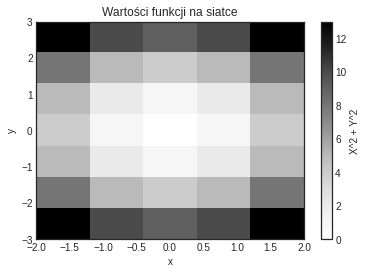

In [27]:
plt.figure(figsize=(6, 4))
plt.imshow(Z, origin='lower', aspect='auto',
           extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar(label="X^2 + Y^2")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Wartości funkcji na siatce")
plt.show()

### Zadanie
1. Zamień funkcję na `Z = np.sin(X) + np.cos(Y)`.
2. Zmień liczbę punktów w `linspace`.
3. Zobacz, jak zmienia się „gładkość” obrazu.

## Ćwiczenie 10 — przygotowanie punktów do `evaluate`

W KDE było:

```python
np.vstack([Xgrid.ravel(), Ygrid.ravel()])

In [29]:
np.vstack([Xgrid.ravel(), Ygrid.ravel()])

array([[-3.5       , -3.32051282, -3.14102564, ...,  3.14102564,
         3.32051282,  3.5       ],
       [-6.        , -6.        , -6.        , ...,  6.        ,
         6.        ,  6.        ]])

In [31]:

### Code

xgrid = np.linspace(-1, 1, 3)
ygrid = np.linspace(10, 20, 4)

Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)

points = np.vstack([Xgrid.ravel(), Ygrid.ravel()])

print("Xgrid:")
print(Xgrid)

print("\nYgrid:")
print(Ygrid)

print("\npoints:")
print(points)
print("shape:", points.shape)

Xgrid:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

Ygrid:
[[10.         10.         10.        ]
 [13.33333333 13.33333333 13.33333333]
 [16.66666667 16.66666667 16.66666667]
 [20.         20.         20.        ]]

points:
[[-1.          0.          1.         -1.          0.          1.
  -1.          0.          1.         -1.          0.          1.        ]
 [10.         10.         10.         13.33333333 13.33333333 13.33333333
  16.66666667 16.66666667 16.66666667 20.         20.         20.        ]]
shape: (2, 12)


### Co oznaczają kolumny `points`?

Każda kolumna to jeden punkt:
- pierwsza kolumna = pierwszy punkt,
- druga kolumna = drugi punkt,
- itd.

Czyli:
\[
\text{points} =
\begin{bmatrix}
x_1 & x_2 & x_3 & \dots \\
y_1 & y_2 & y_3 & \dots
\end{bmatrix}
\]

In [32]:
for i in range(points.shape[1]):
    print(f"Punkt {i}: ({points[0, i]}, {points[1, i]})")

Punkt 0: (-1.0, 10.0)
Punkt 1: (0.0, 10.0)
Punkt 2: (1.0, 10.0)
Punkt 3: (-1.0, 13.333333333333334)
Punkt 4: (0.0, 13.333333333333334)
Punkt 5: (1.0, 13.333333333333334)
Punkt 6: (-1.0, 16.666666666666668)
Punkt 7: (0.0, 16.666666666666668)
Punkt 8: (1.0, 16.666666666666668)
Punkt 9: (-1.0, 20.0)
Punkt 10: (0.0, 20.0)
Punkt 11: (1.0, 20.0)


## Zadanie końcowe

Zrób samodzielnie:

1. Utwórz:
   - `xgrid = np.linspace(-2, 2, 6)`
   - `ygrid = np.linspace(-1, 1, 5)`

2. Zbuduj:
   - `Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)`

3. Spłaszcz:
   - `xr = Xgrid.ravel()`
   - `yr = Ygrid.ravel()`

4. Złóż:
   - `points = np.vstack([xr, yr])`

5. Wypisz:
   - kształty wszystkich obiektów

6. Narysuj punkty:
   - `plt.scatter(xr, yr)`

<!--NAVIGATION-->
< [Density and Contour Plots](04.04-Density-and-Contour-Plots.ipynb) | [Contents](Index.ipynb) | [Customizing Plot Legends](04.06-Customizing-Legends.ipynb) >

<a href="https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.05-Histograms-and-Binnings.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>
